# King County Housing Price Prediction
**Machine Learning Capstone — Review 1**  
**Dataset:** `kc_house_data.csv`

This notebook walks through an end-to-end regression workflow: exploratory data analysis, data cleaning, feature engineering, and a benchmark across 10 distinct regression algorithms using an 80:20 train-test split. We also run hyperparameter optimization across 4 diverse estimators and examine error diagnostics for the best-performing ensemble.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 10 Regression Algorithms
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
np.random.seed(42)

# Container for benchmark tracking
benchmark_results = {}

def evaluate_preds(name, y_true, y_pred):
    r2 = float(r2_score(y_true, y_pred))
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    
    benchmark_results[name] = {
        'R2 Score': round(r2, 4),
        'RMSE ($)': round(rmse, 2),
        'MAE ($)': round(mae, 2)
    }
    
    print(f"[{name}]")
    print(f"  R2:   {r2:.4f}")
    print(f"  RMSE: ${rmse:,.2f}")
    print(f"  MAE:  ${mae:,.2f}\n")
    
    return r2, rmse, mae

## 1. Dataset Audit & Exploratory Data Analysis
Let's inspect the shapes, column types, null values, and check summary statistics for home sale prices.

In [24]:
df_raw = pd.read_csv('kc_house_data.csv')

print(f"Dataset Dimensions: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
print("\n--- Column Data Types ---")
print(df_raw.dtypes)
print("\n--- Missing Values Count ---")
print(df_raw.isnull().sum())
print("\n--- Duplicate Rows ---")
print(f"Duplicates detected: {df_raw.duplicated().sum()}")
print("\n--- Target Summary (price) ---")
print(df_raw['price'].describe())

Dataset Dimensions: 21613 rows, 21 columns

--- Column Data Types ---
id                 int64
date                 str
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

--- Missing Values Count ---
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0


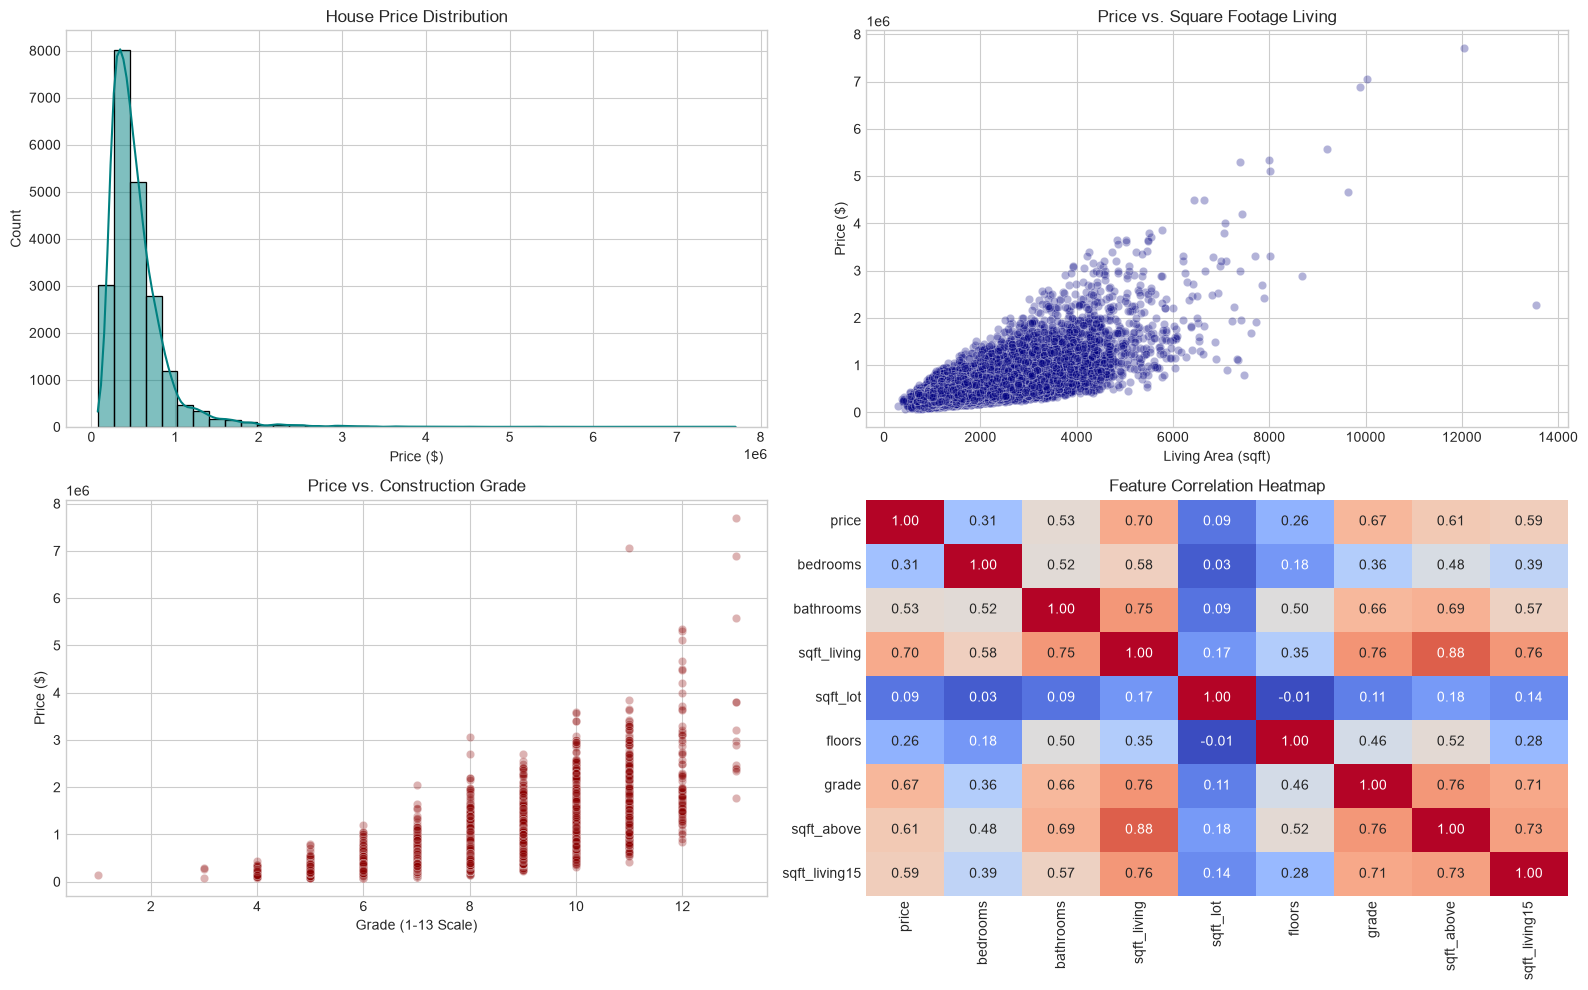

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Target Distribution
sns.histplot(df_raw['price'], kde=True, ax=axes[0, 0], color='teal', bins=40)
axes[0, 0].set_title('House Price Distribution')
axes[0, 0].set_xlabel('Price ($)')

# 2. Living Area vs Price
sns.scatterplot(data=df_raw, x='sqft_living', y='price', alpha=0.3, ax=axes[0, 1], color='navy')
axes[0, 1].set_title('Price vs. Square Footage Living')
axes[0, 1].set_xlabel('Living Area (sqft)')
axes[0, 1].set_ylabel('Price ($)')

# 3. Construction Grade vs Price
sns.scatterplot(data=df_raw, x='grade', y='price', alpha=0.3, ax=axes[1, 0], color='darkred')
axes[1, 0].set_title('Price vs. Construction Grade')
axes[1, 0].set_xlabel('Grade (1-13 Scale)')
axes[1, 0].set_ylabel('Price ($)')

# 4. Correlation Heatmap
core_cols = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'grade', 'sqft_above', 'sqft_living15']
sns.heatmap(df_raw[core_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', ax=axes[1, 1], cbar=False)
axes[1, 1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

### EDA Observations:
* **Right-skewed target:** Most homes sell between USD 300,000 and USD 650,000, with a long tail of luxury properties stretching past USD 7,000,000.
* **Living area correlation:** `sqft_living` displays a strong positive linear relationship with price ($r = 0.70$). The variance widens noticeably for properties over 4,000 sqft.
* **Exponential grade impact:** Construction grade shows an exponential jump. Prices remain fairly stable between grades 5 and 7, but accelerate sharply once a home reaches grade 9 or above.
* **Multicollinearity:** Features like `sqft_living`, `sqft_above`, and `sqft_living15` show correlations exceeding 0.75, which will cause instability in standard unregularized linear models.

## 2. Preprocessing & Feature Engineering
* **`house_age`:** The raw `yr_built` column is just a calendar year. Subtracting it from `yr_sold` gives the actual age of the house when it was bought, which is a much cleaner signal for structural wear and tear.
* **`is_renovated`:** More than 95% of houses have `yr_renovated = 0`. Leaving it as a raw year messes up linear weights. Turning it into a simple binary flag (1 for renovated, 0 for never renovated) keeps things clean.
* **Dropped columns:** We removed `id`, `date`, and raw year columns so the model doesn't memorize arbitrary record numbers or double-count time.
* **Scaling on Train Only:** `StandardScaler` is fitted only on `X_train` and then used to transform `X_test`. If we fitted on the whole dataset first, test set statistics would bleed into training.

In [6]:
df = df_raw.copy()

# Remove arbitrary identifier
df = df.drop(columns=['id'])

# Feature Engineering
df['yr_sold'] = pd.to_datetime(df['date']).dt.year
df['house_age'] = df['yr_sold'] - df['yr_built']
df['is_renovated'] = (df['yr_renovated'] > 0).astype(int)

# Drop raw date/year columns
df = df.drop(columns=['date', 'yr_sold', 'yr_built', 'yr_renovated'])

# Separate predictors and target
X = df.drop(columns=['price'])
y = df['price']

# 80:20 Train-Test Split (fixed seed)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Standard Scaling fitted strictly on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")

X_train shape: (17290, 18) | X_test shape: (4323, 18)


## 3. Training 10 Regression Algorithms
We evaluate 10 individual algorithms on the same 20% test partition. Linear, regularized, and distance-based estimators run on standard-scaled inputs, while decision trees and tree ensembles run on raw numerical features.

### Model 1: Linear Regression (OLS Baseline)
Standard unregularized ordinary least squares regression.

In [22]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

evaluate_preds("1. Linear Regression", y_test, lr_preds)

[1. Linear Regression]
  R2:   0.7014
  RMSE: $212,471.41
  MAE:  $127,417.12



(0.7013819165844589, 212471.41000898273, 127417.12289531033)

### Model 2: Ridge Regression ($L_2$ Regularization)
Adds an $L_2$ norm penalty to shrink coefficients and stabilize multicollinear square-footage features.

In [21]:
ridge_model = Ridge(alpha=10.0, random_state=42)
ridge_model.fit(X_train_scaled, y_train)
ridge_preds = ridge_model.predict(X_test_scaled)

evaluate_preds("2. Ridge Regression", y_test, ridge_preds)

[2. Ridge Regression]
  R2:   0.7014
  RMSE: $212,477.56
  MAE:  $127,397.73



(0.7013646348546527, 212477.5580297822, 127397.73268311696)

### Model 3: Lasso Regression ($L_1$ Regularization)
Uses an $L_1$ penalty to drive minor coefficients to absolute zero, acting as automatic feature selection.

In [20]:
lasso_model = Lasso(alpha=100.0, max_iter=10000, random_state=42)
lasso_model.fit(X_train_scaled, y_train)
lasso_preds = lasso_model.predict(X_test_scaled)

evaluate_preds("3. Lasso Regression", y_test, lasso_preds)

[3. Lasso Regression]
  R2:   0.7013
  RMSE: $212,499.40
  MAE:  $127,380.89



(0.7013032222904156, 212499.40427175813, 127380.88677674528)

### Model 4: ElasticNet Regression
Combines both $L_1$ and $L_2$ regularization penalties (`l1_ratio=0.5`).

In [19]:
elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000, random_state=42)
elastic_model.fit(X_train_scaled, y_train)
elastic_preds = elastic_model.predict(X_test_scaled)

evaluate_preds("4. ElasticNet Regression", y_test, elastic_preds)

[4. ElasticNet Regression]
  R2:   0.6991
  RMSE: $213,273.39
  MAE:  $126,207.19



(0.6991233736195372, 213273.39067762988, 126207.19470075882)

### Model 5: Polynomial Regression (Degree 2)
Expands features into degree-2 interaction combinations, regularized with a Ridge penalty.

In [23]:
poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scale', StandardScaler()),
    ('ridge', Ridge(alpha=100.0, random_state=42))
])
poly_pipeline.fit(X_train, y_train)
poly_preds = poly_pipeline.predict(X_test)

evaluate_preds("5. Polynomial Regression", y_test, poly_preds)

[5. Polynomial Regression]
  R2:   0.7542
  RMSE: $192,777.59
  MAE:  $112,419.08



(0.754173774762753, 192777.59340203542, 112419.08453533657)